In [1]:
import pandas as pd 

In [4]:
df = pd.read_csv('Loan_Data.csv')

In [5]:
df.shape

(10000, 8)

In [6]:
df.columns

Index(['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding',
       'total_debt_outstanding', 'income', 'years_employed', 'fico_score',
       'default'],
      dtype='object')

In [8]:
df.isna().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [1]:
import pandas as pd
# Load the actual file your training script uses
X_train = pd.read_csv("data/processed/X_train.csv")

print("--- ACTUAL FEATURES IN TRAINING ---")
print(X_train.columns.tolist())

--- ACTUAL FEATURES IN TRAINING ---
['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']


In [2]:
%pip install seaborn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your processed data
X = pd.read_csv("data/processed/X_train.csv")
y = pd.read_csv("data/processed/y_train.csv")
df = pd.concat([X, y], axis=1)

# Check correlation
correlations = df.corr()['default'].sort_values(ascending=False)
print(correlations)

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
default                     1.000000
credit_lines_outstanding    0.864067
total_debt_outstanding      0.761684
loan_amt_outstanding        0.101524
income                      0.018107
years_employed             -0.284910
fico_score                 -0.327351
Name: default, dtype: float64


In [3]:
import pandas as pd
df = pd.read_csv("data/Loan_Data.csv")
print(df['default'].value_counts(normalize=True))


default
0    0.8149
1    0.1851
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Loan Amt Distribution (Skew: 0.42)')

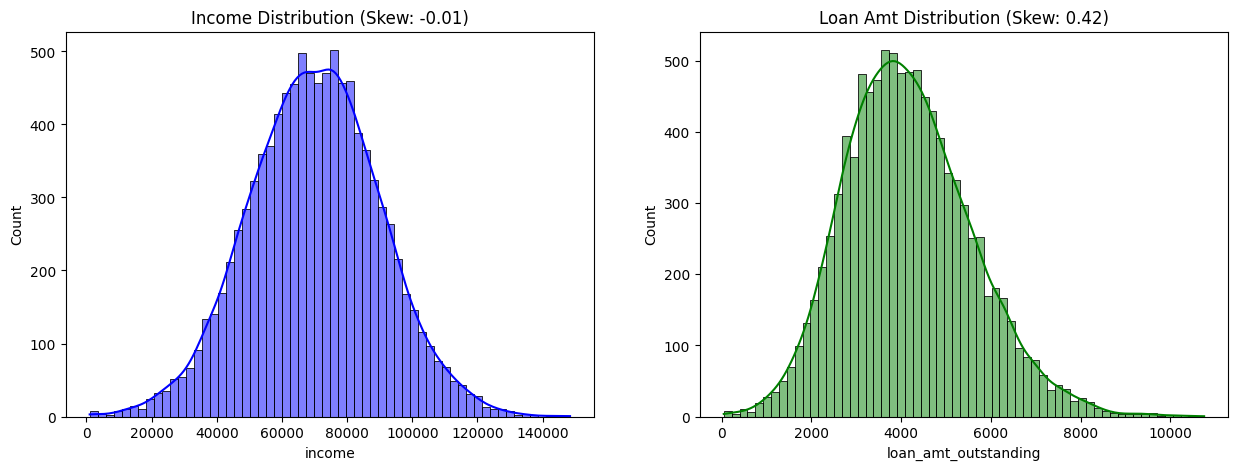

In [4]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Income Distribution
sns.histplot(df['income'], kde=True, ax=axes[0], color='blue')
axes[0].set_title(f"Income Distribution (Skew: {df['income'].skew():.2f})")

# 2. Loan Amount Distribution
sns.histplot(df['loan_amt_outstanding'], kde=True, ax=axes[1], color='green')
axes[1].set_title(f"Loan Amt Distribution (Skew: {df['loan_amt_outstanding'].skew():.2f})")